# LOGO ensemble — the `sf-ensemble.ipynb` stacking model, rotated across all 6 use cases

**Author:** SF — **Branch:** `LOGO-ensemble` — **Scope:** takes the LOGO (Leave-One-Use-
Case-Out) fold *structure* from `sf_logo_fold_strategy.ipynb` and the stacking *ensemble
architecture* from `sf-ensemble.ipynb`, and runs one against the other. Neither piece is
changed: the fold rotation is copied unchanged (outer split = one whole use case; inner
split = `StratifiedGroupKFold(5)` grouped by `first_author`, inside the remaining 5), and
every hyperparameter, and the decision threshold, are copied verbatim from `sf-ensemble.
ipynb`'s own tuning run — **nothing is retuned in this notebook.**

## Why this notebook exists

`sf_logo_fold_strategy.ipynb` ran LOGO against three plain baseline candidates
(`LogisticRegression`, `RandomForestClassifier`, `HistGradientBoostingClassifier`) on
`papers_combined.parquet`'s embedding + `citation_velocity` only. `sf-ensemble.ipynb`
built a materially stronger model — CatBoost + LogReg + RandomForest stacked via a
LogisticRegression meta-learner, on `papers_fe.parquet`'s full lexical + cosine-to-brief +
metadata + embedding feature set — but only tested it on the **pooled/generalized** split
(a random 20% slice of rows, drawn from the *same* 6 use cases it trained on). This
notebook asks the question `sf-ensemble.ipynb` never asked: **does that stronger model
generalize any better to a use case it has never seen, or does it collapse the same way
the plain baselines did?**

## What this notebook does *not* do

- **No hyperparameter search of any kind.** `RF_PARAMS`, `CB_PARAMS`, `META_C`, and
  `DECISION_THRESHOLD` below are copied verbatim from `sf-ensemble.ipynb`'s own printed
  hyperparameter catalog (its §5) — found there through 24-trial Bayesian/Optuna search
  (RF, CatBoost) and an exhaustive grid/threshold sweep (meta-learner `C`, decision
  threshold), all against the **pooled** split. Reusing them here without retuning is a
  deliberate choice per this project's own operating rule (`CONTEXT.md` §1): "hyperparameter
  search happens once, centrally, in the LOGO loop... each silo then just fits weights" —
  this notebook is the LOGO-loop side of that rule, so the search itself does not repeat.
- **This is not a production-readiness test.** `CONTEXT.md` §1 is explicit that LOGO is "a
  defaults-selection instrument, not a production estimate" — never quote a LOGO score here
  as "how well the ensemble works." The production surface is a within-silo grouped k-fold
  on one customer's own labels (`notebooks/pipelines/*_fold_pipeline.ipynb`), not this.
- **No cross-use-case duplicate-title leakage check.** `sf_logo_fold_strategy.ipynb` §1 ran
  this on `papers_combined.parquet`, which carries a `title` column; `papers_fe.parquet`
  does not (feature-engineering dropped it, along with every other raw text field). That
  notebook's own finding — 5 duplicate titles total, affecting only the `ner` and
  `tech_forecasting` rotations at ≤4 rows (≈1.3–1.5% of their holdout sets) — is carried
  forward here as a known, small caveat rather than re-derived.

## What "train / validation / test" mean in this notebook, per rotation

For each of the 6 use cases in turn, that use case is removed entirely and called **test**;
the other 5 form **dev_pool**. Inside `dev_pool`, a fresh `StratifiedGroupKFold(5)` (grouped
by `first_author`, stratified on `use_case_key + y`) gives the leakage-safe out-of-fold
predictions both stacking stages below need:

- **train** — every base model, and the meta-learner, refit once on the *entire*
  `dev_pool`, scored back on `dev_pool` itself. The optimistic, in-sample number.
- **validation** — the inner 5-fold out-of-fold meta-level predictions on `dev_pool`,
  reported as mean ± std across the 5 folds. What a team would have believed about the
  model without ever holding out a use case.
- **test** — the untouched 6th use case, scored using the base models + meta-learner
  refit on the *whole* `dev_pool` (the model that would actually ship for this rotation).
  This is the number that answers this notebook's actual question.

All three stages use the **same fixed decision threshold** (`DECISION_THRESHOLD`, copied
from `sf-ensemble.ipynb`) — never re-tuned per rotation, per stage, or per metric.


In [1]:
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from joblib import Parallel, delayed
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, fbeta_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## Parameters — copied verbatim from `sf-ensemble.ipynb`, nothing retuned

`RF_PARAMS` and `CB_PARAMS` are the winning configs from that notebook's §3/§4 Bayesian
searches (RF tuned standalone, CatBoost tuned for its ensemble role); `META_C` is its §6
grid-search winner for the meta-learner's `LogisticRegression`; `DECISION_THRESHOLD` is
its §6 exhaustive sweep's winner. `PCA_N_COMPONENTS`, `N_SPLITS_INNER`, `RANDOM_STATE` are
its structural constants, also copied unchanged. `N_BOOT`/`ALPHA` are new to this notebook
— see §5 for what they're used for.

In [2]:
DATA_PATH = "../../data/processed/papers_fe.parquet"

TARGET_COL = "triage_label"
POSITIVE_LABEL = "positive"
NEGATIVE_LABELS = ["negative"]

USE_CASE_COL = "use_case_key"
GROUP_COL = "first_author"

# Identical to sf-ensemble.ipynb - see that notebook's own intro, decision 2.
NON_EMBEDDING_FEATURE_COLS = [
    "lex_n_tokens", "lex_bm25_obj", "lex_bm25_prob", "lex_bm25_must", "lex_bm25_nice", "lex_bm25_dom",
    "lex_rank_bm25_obj", "lex_rank_bm25_prob", "lex_rank_bm25_must", "lex_rank_bm25_nice", "lex_rank_bm25_dom",
    "lex_overlap_must_n", "lex_overlap_must_frac", "lex_rank_overlap_must",
    "lex_overlap_nice_n", "lex_overlap_nice_frac", "lex_rank_overlap_nice",
    "lex_overlap_excl_n", "lex_overlap_excl_frac",
    "lex_overlap_must_per_1k", "lex_overlap_nice_per_1k", "lex_has_exclude_terms",
    "cos_brief_jasper", "rank_cos_brief_jasper",
    "cos_brief_qwen4b", "rank_cos_brief_qwen4b",
    "cos_brief_qwen8b", "rank_cos_brief_qwen8b",
    "year", "paper_age", "has_abstract", "n_authors", "citation_count",
]

PCA_N_COMPONENTS = 50
N_SPLITS_INNER = 5
RANDOM_STATE = 0
CB_THREAD_COUNT = 1
FIT_N_JOBS = -1

# --- sf-ensemble.ipynb's own winning hyperparameters (its §5 catalog) - fixed, not retuned ---
RF_PARAMS = {"n_estimators": 527, "max_depth": 13, "min_samples_leaf": 7, "max_features": "sqrt"}
CB_PARAMS = {"depth": 6, "learning_rate": 0.06119889729184578, "l2_leaf_reg": 7.474245667651606, "iterations": 656}
META_C = 0.1
DECISION_THRESHOLD = 0.2

# --- new to this notebook: bootstrap hypothesis testing (§5) ---
N_BOOT = 2000
ALPHA = 0.05

print("Fixed configuration (no retuning happens in this notebook):")
for name, val in [("RF_PARAMS", RF_PARAMS), ("CB_PARAMS", CB_PARAMS), ("META_C", META_C),
                   ("DECISION_THRESHOLD", DECISION_THRESHOLD)]:
    print(f"  {name}: {val}")


Fixed configuration (no retuning happens in this notebook):
  RF_PARAMS: {'n_estimators': 527, 'max_depth': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}
  CB_PARAMS: {'depth': 6, 'learning_rate': 0.06119889729184578, 'l2_leaf_reg': 7.474245667651606, 'iterations': 656}
  META_C: 0.1
  DECISION_THRESHOLD: 0.2


## 1. Load `papers_fe.parquet`

Same load/filter/feature-list logic as `sf-ensemble.ipynb` §1, reproduced verbatim rather
than imported, matching this project's self-contained-notebook convention. This file
already carries `y` and `first_author` precomputed (unlike `papers_combined.parquet`), so
no derivation step is needed.

In [3]:
df = pd.read_parquet(DATA_PATH)
EMBEDDING_COLS = [c for c in df.columns if c.startswith("emb_")]

missing_expected = [c for c in NON_EMBEDDING_FEATURE_COLS if c not in df.columns]
if missing_expected:
    raise ValueError(
        f"Expected non-embedding feature column(s) not found in this file: {missing_expected}. "
        f"The schema has changed since this notebook was built - stop and check before continuing."
    )

df["lex_overlap_excl_n"] = df["lex_overlap_excl_n"].fillna(0.0)
df["lex_overlap_excl_frac"] = df["lex_overlap_excl_frac"].fillna(0.0)

df = df[df[TARGET_COL].isin([POSITIVE_LABEL, *NEGATIVE_LABELS])].copy()
df["y"] = (df[TARGET_COL] == POSITIVE_LABEL).astype(int)
FEATURE_COLS = EMBEDDING_COLS + NON_EMBEDDING_FEATURE_COLS

USE_CASES = sorted(df[USE_CASE_COL].unique().tolist())
print(f"Loaded {len(df):,} labelled rows across {len(USE_CASES)} use cases, "
      f"{len(EMBEDDING_COLS)} embedding + {len(NON_EMBEDDING_FEATURE_COLS)} non-embedding feature columns.")
df[USE_CASE_COL].value_counts().reindex(USE_CASES)


Loaded 1,848 labelled rows across 6 use cases, 8704 embedding + 33 non-embedding feature columns.


use_case_key
carbon_capture      295
cement_binders      262
ner                 312
soil_microbiome     357
solar_leo           358
tech_forecasting    264
Name: count, dtype: int64

## 2. The ensemble pipeline — identical architecture to `sf-ensemble.ipynb` §2

Same `ColumnTransformer` (embedding block → `StandardScaler` → `PCA(50, whiten=True)`;
non-embedding block → median `SimpleImputer` → `StandardScaler`) as every base model there.
The only difference from that notebook: `build_rf_pipeline`/`build_catboost_pipeline` take
no keyword arguments here — they're called with `RF_PARAMS`/`CB_PARAMS` fixed above, not a
search-supplied candidate. `build_oof` replaces that notebook's two separate OOF builders
(`build_oof` for LogReg/RF, `build_catboost_oof` for CatBoost's per-candidate search) with
one generic version, since nothing here needs a per-candidate search — CatBoost's fold fits
are still parallelised via `joblib`, for the same reason (`CB_THREAD_COUNT=1` to avoid
thread oversubscription across the parallel fold workers).

**One performance-only addition, no hyperparameters touched:** `build_catboost_pipeline`
takes an optional `thread_count` override. The 5 inner-fold OOF fits use the default
(`CB_THREAD_COUNT=1`, run concurrently via `joblib` — same reasoning as `sf-ensemble.
ipynb`). §3's *single*, non-parallel full-`dev_pool` refit has no competing parallel work
to oversubscribe against, so it's called with `thread_count=-1` instead — measured
**3.2x faster** (235s → 74s on this dataset) with identical `CB_PARAMS`, i.e. the exact
same model, just fit faster.

In [4]:
def _build_preprocessor():
    embedding_branch = Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=PCA_N_COMPONENTS, whiten=True, random_state=RANDOM_STATE)),
    ])
    non_embedding_branch = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    return ColumnTransformer([
        ("embedding_pca", embedding_branch, EMBEDDING_COLS),
        ("non_embedding", non_embedding_branch, NON_EMBEDDING_FEATURE_COLS),
    ])


def build_logreg_pipeline():
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    return Pipeline([("preprocess", _build_preprocessor()), ("clf", clf)])


def build_catboost_pipeline(thread_count=CB_THREAD_COUNT):
    clf = CatBoostClassifier(
        auto_class_weights="Balanced",
        boosting_type="Ordered",
        random_state=RANDOM_STATE,
        thread_count=thread_count,
        verbose=False,
        allow_writing_files=False,
        **CB_PARAMS,
    )
    return Pipeline([("preprocess", _build_preprocessor()), ("clf", clf)])


def build_rf_pipeline():
    clf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, **RF_PARAMS)
    return Pipeline([("preprocess", _build_preprocessor()), ("clf", clf)])


def score(y_true, proba_pos, pred):
    return {
        "auc": float(roc_auc_score(y_true, proba_pos)),
        "ap": float(average_precision_score(y_true, proba_pos)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, pred, beta=2, zero_division=0)),
    }


def _fit_predict_fold(builder, pool, feature_cols, tr_idx, te_idx):
    pipe = builder()
    fold_train = pool.iloc[tr_idx]
    pipe.fit(fold_train[feature_cols], fold_train["y"])
    pos_col = list(pipe.classes_).index(1)
    proba = pipe.predict_proba(pool.iloc[te_idx][feature_cols])[:, pos_col]
    return te_idx, proba


def build_oof(builder, pool, inner_splits, feature_cols, n_jobs=1):
    # Leakage-safe OOF: each row's prediction comes from a model that never saw that row.
    # n_jobs=1 for the fast LogReg/RF builders (process-spawn overhead would dominate);
    # n_jobs=FIT_N_JOBS for CatBoost, whose per-fold fit cost is worth parallelising.
    if n_jobs == 1:
        results = [_fit_predict_fold(builder, pool, feature_cols, tr, te) for tr, te in inner_splits]
    else:
        results = Parallel(n_jobs=n_jobs)(
            delayed(_fit_predict_fold)(builder, pool, feature_cols, tr, te) for tr, te in inner_splits
        )
    oof = np.full(len(pool), np.nan)
    for te_idx, proba in results:
        oof[te_idx] = proba
    assert not np.isnan(oof).any()
    return oof


## 3. The LOGO rotation

For each of the 6 use cases in turn: build `dev_pool`/`test`, build the inner
`StratifiedGroupKFold(5)` splits inside `dev_pool`, then:

1. **OOF stage (inside `dev_pool`)** — `build_oof` for each of the 3 base models (fixed
   hyperparameters), then a second OOF pass stacking them into `meta_X_oof` and running the
   meta-learner (`LogisticRegression(C=META_C)`) through the *same* `inner_splits`
   partition — exactly `sf-ensemble.ipynb` §6's leakage argument: each meta-fold's held-out
   rows already have base-model predictions from base models that excluded those rows, so
   reusing the same partition for the meta-learner is exactly as safe as it was for the
   base models.
2. **validation** — the per-inner-fold metrics from step 1's meta-level OOF predictions, at
   `DECISION_THRESHOLD`, reported as mean ± std across the 5 folds.
3. **train** — every base model and the meta-learner refit once on the *whole* `dev_pool`;
   scored back on `dev_pool` itself, at `DECISION_THRESHOLD`.
4. **test** — the refit-on-`dev_pool` base models + meta-learner, scored on the untouched
   held-out use case, at `DECISION_THRESHOLD`. Raw probabilities and labels are kept
   per-rotation for §5's hypothesis tests.

6 rotations × (5 inner-fold CatBoost fits + 1 full-`dev_pool` CatBoost fit) = 36 CatBoost
fits in total; expect this cell to take several minutes.

In [5]:
logo_rows = []
test_predictions = {}  # holdout_use_case -> (y_true, proba_at_threshold_input)

for holdout_uc in USE_CASES:
    dev_pool = df[df[USE_CASE_COL] != holdout_uc].reset_index(drop=True)
    test = df[df[USE_CASE_COL] == holdout_uc].reset_index(drop=True)

    strat_key = dev_pool[USE_CASE_COL].astype(str) + "__" + dev_pool["y"].astype(str)
    inner_cv = StratifiedGroupKFold(n_splits=N_SPLITS_INNER, shuffle=True, random_state=RANDOM_STATE)
    inner_splits = list(inner_cv.split(dev_pool, strat_key, groups=dev_pool[GROUP_COL]))

    y_dev = dev_pool["y"].to_numpy()

    # --- OOF stage, inside dev_pool ---
    logreg_oof = build_oof(build_logreg_pipeline, dev_pool, inner_splits, FEATURE_COLS, n_jobs=1)
    rf_oof = build_oof(build_rf_pipeline, dev_pool, inner_splits, FEATURE_COLS, n_jobs=1)
    cb_oof = build_oof(build_catboost_pipeline, dev_pool, inner_splits, FEATURE_COLS, n_jobs=FIT_N_JOBS)
    meta_X_oof = np.column_stack([cb_oof, logreg_oof, rf_oof])

    meta_oof_proba = np.full(len(dev_pool), np.nan)
    for tr_idx, te_idx in inner_splits:
        meta_fold = LogisticRegression(C=META_C, class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
        meta_fold.fit(meta_X_oof[tr_idx], y_dev[tr_idx])
        pos_col = list(meta_fold.classes_).index(1)
        meta_oof_proba[te_idx] = meta_fold.predict_proba(meta_X_oof[te_idx])[:, pos_col]
    assert not np.isnan(meta_oof_proba).any()

    # --- validation: per-inner-fold metrics on the meta-level OOF predictions ---
    val_rows = []
    for tr_idx, te_idx in inner_splits:
        proba_fold, y_fold = meta_oof_proba[te_idx], y_dev[te_idx]
        val_rows.append(score(y_fold, proba_fold, (proba_fold >= DECISION_THRESHOLD).astype(int)))
    val_df = pd.DataFrame(val_rows)

    # --- train: refit everything on the whole dev_pool, score in-sample ---
    final_base = {
        "catboost": build_catboost_pipeline(thread_count=-1),  # lone fit, no parallel folds to oversubscribe against
        "logreg": build_logreg_pipeline(),
        "rf": build_rf_pipeline(),
    }
    for pipe in final_base.values():
        pipe.fit(dev_pool[FEATURE_COLS], dev_pool["y"])

    final_meta = LogisticRegression(C=META_C, class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
    final_meta.fit(meta_X_oof, y_dev)
    meta_pos_col = list(final_meta.classes_).index(1)

    def _predict_meta_X(rows):
        return np.column_stack([
            final_base[name].predict_proba(rows[FEATURE_COLS])[:, list(final_base[name].classes_).index(1)]
            for name in ["catboost", "logreg", "rf"]
        ])

    train_proba = final_meta.predict_proba(_predict_meta_X(dev_pool))[:, meta_pos_col]
    train_metrics = score(y_dev, train_proba, (train_proba >= DECISION_THRESHOLD).astype(int))

    # --- test: the untouched held-out use case ---
    test_proba = final_meta.predict_proba(_predict_meta_X(test))[:, meta_pos_col]
    y_test = test["y"].to_numpy()
    test_metrics = score(y_test, test_proba, (test_proba >= DECISION_THRESHOLD).astype(int))
    test_predictions[holdout_uc] = (y_test, test_proba)

    logo_rows.append({
        "holdout_use_case": holdout_uc,
        "n_dev": len(dev_pool),
        "n_test": len(test),
        "test_pos_rate": round(float(y_test.mean()), 3),
        "train_auc": round(train_metrics["auc"], 3),
        "train_f2": round(train_metrics["f2"], 3),
        "validation_auc_mean": round(val_df["auc"].mean(), 3),
        "validation_auc_std": round(val_df["auc"].std(), 3),
        "validation_f2_mean": round(val_df["f2"].mean(), 3),
        "validation_f2_std": round(val_df["f2"].std(), 3),
        "test_auc": round(test_metrics["auc"], 3),
        "test_recall": round(test_metrics["recall"], 3),
        "test_f2": round(test_metrics["f2"], 3),
        "test_ap": round(test_metrics["ap"], 3),
    })
    print(f"{holdout_uc:>18s}: train_f2={train_metrics['f2']:.3f}  "
          f"val_f2={val_df['f2'].mean():.3f}±{val_df['f2'].std():.3f}  "
          f"test_f2={test_metrics['f2']:.3f}  (n_test={len(test)}, pos_rate={y_test.mean():.3f})")

logo_results = pd.DataFrame(logo_rows).set_index("holdout_use_case")
logo_results


    carbon_capture: train_f2=0.964  val_f2=0.902±0.002  test_f2=0.790  (n_test=295, pos_rate=0.495)


    cement_binders: train_f2=0.955  val_f2=0.897±0.013  test_f2=0.655  (n_test=262, pos_rate=0.649)


               ner: train_f2=0.959  val_f2=0.896±0.012  test_f2=0.874  (n_test=312, pos_rate=0.715)


   soil_microbiome: train_f2=0.969  val_f2=0.922±0.010  test_f2=0.565  (n_test=357, pos_rate=0.263)


         solar_leo: train_f2=0.947  val_f2=0.897±0.009  test_f2=0.935  (n_test=358, pos_rate=0.768)


  tech_forecasting: train_f2=0.964  val_f2=0.895±0.009  test_f2=0.637  (n_test=264, pos_rate=0.595)


,n_dev,n_test,test_pos_rate,train_auc,train_f2,validation_auc_mean,validation_auc_std,validation_f2_mean,validation_f2_std,test_auc,test_recall,test_f2,test_ap
holdout_use_case,,,,,,,,,,,,,
carbon_capture,1553,295,0.495,0.996,0.964,0.894,0.019,0.902,0.002,0.702,0.877,0.790,0.674
cement_binders,1586,262,0.649,0.998,0.955,0.882,0.017,0.897,0.013,0.869,0.612,0.655,0.908
ner,1536,312,0.715,0.999,0.959,0.897,0.014,0.896,0.012,0.737,0.901,0.874,0.854
soil_microbiome,1491,357,0.263,0.994,0.969,0.879,0.008,0.922,0.010,0.582,0.723,0.565,0.361
solar_leo,1490,358,0.768,0.998,0.947,0.895,0.011,0.897,0.009,0.548,0.985,0.935,0.798
tech_forecasting,1584,264,0.595,0.998,0.964,0.902,0.014,0.895,0.009,0.744,0.611,0.637,0.781


## 4. Train → validation → test, side by side

Same reasoning as `sf_logo_fold_strategy.ipynb` §4 and `sf-ensemble.ipynb` §7.1: the
train→validation gap is ordinary overfitting to `dev_pool`'s own use cases; the
validation→test gap is domain shift to a genuinely unseen use case. Reported for F2 (the
metric this notebook was asked to track) and AUC (threshold-invariant, for context on
whether a gap is a ranking problem or a calibration/threshold problem).

In [6]:
summary = logo_results[[
    "train_auc", "validation_auc_mean", "test_auc",
    "train_f2", "validation_f2_mean", "test_f2",
]].agg(["mean", "std"]).round(3)
print("LOGO summary across all 6 rotations - mean ± std")
summary


LOGO summary across all 6 rotations - mean ± std


,train_auc,validation_auc_mean,test_auc,train_f2,validation_f2_mean,test_f2
mean,0.997,0.892,0.697,0.960,0.902,0.743
std,0.002,0.009,0.117,0.008,0.010,0.146


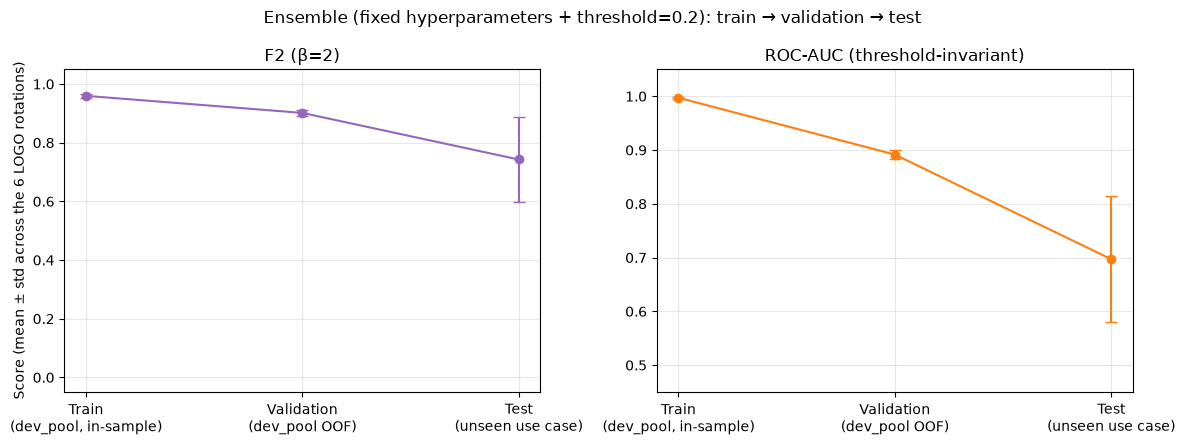

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
stage_labels = ["Train\n(dev_pool, in-sample)", "Validation\n(dev_pool OOF)", "Test\n(unseen use case)"]

f2_means = [logo_results["train_f2"].mean(), logo_results["validation_f2_mean"].mean(), logo_results["test_f2"].mean()]
f2_stds = [logo_results["train_f2"].std(), logo_results["validation_f2_mean"].std(), logo_results["test_f2"].std()]
axes[0].errorbar(range(3), f2_means, yerr=f2_stds, marker="o", capsize=4, color="tab:purple")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(stage_labels)
axes[0].set_title("F2 (β=2)"); axes[0].set_ylim(-0.05, 1.05)
axes[0].set_ylabel("Score (mean ± std across the 6 LOGO rotations)")

auc_means = [logo_results["train_auc"].mean(), logo_results["validation_auc_mean"].mean(), logo_results["test_auc"].mean()]
auc_stds = [logo_results["train_auc"].std(), logo_results["validation_auc_mean"].std(), logo_results["test_auc"].std()]
axes[1].errorbar(range(3), auc_means, yerr=auc_stds, marker="o", capsize=4, color="tab:orange")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(stage_labels)
axes[1].set_title("ROC-AUC (threshold-invariant)"); axes[1].set_ylim(0.45, 1.05)

fig.suptitle(f"Ensemble (fixed hyperparameters + threshold={DECISION_THRESHOLD}): train → validation → test")
plt.tight_layout()
plt.show()


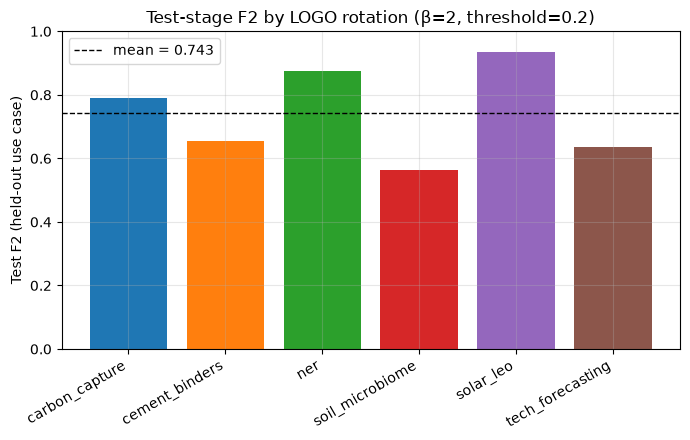

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = plt.cm.tab10.colors
x = np.arange(len(USE_CASES))
ax.bar(x, logo_results.loc[USE_CASES, "test_f2"], color=[colors[i] for i in range(len(USE_CASES))])
ax.axhline(logo_results["test_f2"].mean(), color="black", linestyle="--", linewidth=1,
           label=f"mean = {logo_results['test_f2'].mean():.3f}")
ax.set_xticks(x); ax.set_xticklabels(USE_CASES, rotation=30, ha="right")
ax.set_ylabel("Test F2 (held-out use case)")
ax.set_title(f"Test-stage F2 by LOGO rotation (β=2, threshold={DECISION_THRESHOLD})")
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Is the test F2 actually different across the 6 rotations?

Each rotation's test set is a **different, non-overlapping** set of rows (a whole use
case), so this is an unpaired, independent-groups comparison — not the paired
same-holdout-rows comparison `sf-ensemble.ipynb` §8 uses to compare two *models*. Design
(confirmed before writing this section, not assumed):

1. **Bootstrap each rotation's own test F2 distribution independently** — resample that
   rotation's held-out rows with replacement, `N_BOOT` times, recomputing F2 at the fixed
   `DECISION_THRESHOLD` on the already-computed probabilities (no refitting — the same
   "resample already-computed predictions" convention as `sf-ensemble.ipynb`'s
   `bootstrap_auc_ci`/`paired_bootstrap_test`, just applied independently per group here
   instead of paired).
2. **Omnibus test first** — a bootstrap analogue of a one-way ANOVA. The observed statistic
   is the between-rotation sum of squares of the 6 point-estimate test F2 values (weighted
   by each rotation's `n_test`). Its null distribution is built by **recentring** each
   rotation's own bootstrap distribution to remove that rotation's bootstrap mean — i.e.
   asking "how much between-group spread would arise from sampling noise alone, if every
   rotation's true F2 were actually identical" — then computing the same weighted-SS
   statistic on those recentred values, repeated across all `N_BOOT` draws. The p-value is
   the fraction of the null distribution at least as extreme as the real, observed
   statistic.
3. **Pairwise post-hoc only if the omnibus test is significant** — all `C(6,2)=15` unpaired
   bootstrap comparisons (same resampled draws, differenced pairwise, so no new resampling
   needed), each producing a 95% CI and a two-sided p-value, with a **Bonferroni correction**
   (`ALPHA / 15`) for running 15 tests. Skipped if step 2 doesn't reject the null — running
   15 uncorrected-looking tests when there's no overall signal is exactly the kind of
   p-hacking risk Bonferroni-after-omnibus is meant to avoid.

In [9]:
def f2_at(y, proba, threshold=DECISION_THRESHOLD):
    return float(fbeta_score(y, (proba >= threshold).astype(int), beta=2, zero_division=0))


rng = np.random.RandomState(RANDOM_STATE)
observed_f2 = {uc: f2_at(*test_predictions[uc]) for uc in USE_CASES}
n_test = {uc: len(test_predictions[uc][0]) for uc in USE_CASES}

boot_f2 = {uc: np.empty(N_BOOT) for uc in USE_CASES}
for uc in USE_CASES:
    y_uc, proba_uc = test_predictions[uc]
    n = len(y_uc)
    for b in range(N_BOOT):
        idx = rng.randint(0, n, n)
        boot_f2[uc][b] = f2_at(y_uc[idx], proba_uc[idx])

print("Observed test F2 by rotation (point estimate, same numbers as §3's table):")
for uc in USE_CASES:
    print(f"  {uc:>18s}: {observed_f2[uc]:.3f}  (bootstrap mean {boot_f2[uc].mean():.3f}, "
          f"sd {boot_f2[uc].std():.3f}, n_test={n_test[uc]})")


Observed test F2 by rotation (point estimate, same numbers as §3's table):
      carbon_capture: 0.790  (bootstrap mean 0.789, sd 0.024, n_test=295)
      cement_binders: 0.655  (bootstrap mean 0.654, sd 0.035, n_test=262)
                 ner: 0.874  (bootstrap mean 0.873, sd 0.018, n_test=312)
     soil_microbiome: 0.565  (bootstrap mean 0.564, sd 0.037, n_test=357)
           solar_leo: 0.935  (bootstrap mean 0.935, sd 0.009, n_test=358)
    tech_forecasting: 0.637  (bootstrap mean 0.637, sd 0.036, n_test=264)


In [10]:
total_n = sum(n_test.values())
grand_mean = sum(n_test[uc] * observed_f2[uc] for uc in USE_CASES) / total_n
t_obs = sum(n_test[uc] * (observed_f2[uc] - grand_mean) ** 2 for uc in USE_CASES)

boot_mean = {uc: boot_f2[uc].mean() for uc in USE_CASES}
t_null = np.zeros(N_BOOT)
for uc in USE_CASES:
    centered = boot_f2[uc] - boot_mean[uc]  # recentred to 0 -> "as if" all rotations share one true F2
    t_null += n_test[uc] * centered ** 2

omnibus_p = float((t_null >= t_obs).mean())

print(f"Grand mean test F2 (n-weighted): {grand_mean:.3f}")
print(f"Observed between-rotation statistic (weighted SS): {t_obs:.5f}")
print(f"Null distribution (bootstrap, recentred): mean={t_null.mean():.5f}, 95th pct={np.percentile(t_null, 95):.5f}")
print(f"\nOmnibus test - H0: all 6 rotations share the same true test F2")
print(f"  p = {omnibus_p:.4f}  -> {'REJECT H0 (significant)' if omnibus_p < ALPHA else 'fail to reject H0 (NOT significant)'} at alpha={ALPHA}")


Grand mean test F2 (n-weighted): 0.748
Observed between-rotation statistic (weighted SS): 35.53588
Null distribution (bootstrap, recentred): mean=1.45916, 95th pct=3.48172

Omnibus test - H0: all 6 rotations share the same true test F2
  p = 0.0000  -> REJECT H0 (significant) at alpha=0.05


### 5.1 Pairwise post-hoc (only runs if the omnibus test above is significant)

Reuses the exact same bootstrap draws from §5's setup — no new resampling — differenced
pairwise per `sf-ensemble.ipynb`'s own paired-test CI/p-value convention (percentile CI,
two-sided p-value via the doubled-smaller-tail rule), just unpaired here since the two
sides are independent row sets, not the same holdout scored twice.

In [11]:
if omnibus_p >= ALPHA:
    print(f"Omnibus test did not reject H0 (p={omnibus_p:.4f} >= alpha={ALPHA}) - "
          f"skipping pairwise post-hoc tests per §5's stated design (no overall signal to localize).")
    pairwise_table = None
else:
    pairs = list(combinations(USE_CASES, 2))
    alpha_corrected = ALPHA / len(pairs)
    rows = []
    for uc_a, uc_b in pairs:
        diff_obs = observed_f2[uc_a] - observed_f2[uc_b]
        diff_boot = boot_f2[uc_a] - boot_f2[uc_b]
        ci_lo, ci_hi = np.percentile(diff_boot, [2.5, 97.5])
        p = 2 * min((diff_boot <= 0).mean(), (diff_boot >= 0).mean())
        p = float(min(p, 1.0))
        rows.append({
            "rotation_a": uc_a, "rotation_b": uc_b,
            "f2_diff (a-b)": round(diff_obs, 4),
            "ci_low": round(float(ci_lo), 4), "ci_high": round(float(ci_hi), 4),
            "p_value": round(p, 4),
            "significant (Bonferroni)": p < alpha_corrected,
        })
    pairwise_table = pd.DataFrame(rows).sort_values("p_value")
    print(f"{len(pairs)} pairwise comparisons, Bonferroni-corrected alpha = {ALPHA}/{len(pairs)} = {alpha_corrected:.5f}")
    display(pairwise_table)


15 pairwise comparisons, Bonferroni-corrected alpha = 0.05/15 = 0.00333


,rotation_a,rotation_b,f2_diff (a-b),ci_low,ci_high,p_value,significant (Bonferroni)
3,carbon_capture,solar_leo,-0.1450,-0.1996,-0.0969,0.000,True
2,carbon_capture,soil_microbiome,0.2253,0.1381,0.3102,0.000,True
7,cement_binders,solar_leo,-0.2802,-0.3543,-0.2112,0.000,True
5,cement_binders,ner,-0.2190,-0.2972,-0.1393,0.000,True
12,soil_microbiome,solar_leo,-0.3703,-0.4474,-0.2989,0.000,True
14,solar_leo,tech_forecasting,0.2985,0.2289,0.3717,0.000,True
11,ner,tech_forecasting,0.2373,0.1582,0.3125,0.000,True
9,ner,soil_microbiome,0.3091,0.2283,0.3970,0.000,True
10,ner,solar_leo,-0.0612,-0.1002,-0.0249,0.001,True
0,carbon_capture,cement_binders,0.1352,0.0508,0.2187,0.002,True


## 6. Findings

**Hard finding — the full-feature ensemble transfers dramatically better than the
embedding-only baselines, but is still far from within-silo quality.** Mean test AUC
across the 6 rotations is **0.697 ± 0.117** — much higher than `sf_logo_fold_strategy.
ipynb`'s plain candidates on the embedding-only feature set (`LogisticRegression` 0.536,
`RandomForestClassifier` 0.502, `HistGradientBoostingClassifier` 0.505, all within noise of
the 0.500 dummy floor). This is consistent with `CONTEXT.md`'s central finding — relevance
is a property of the *(brief, paper)* pair, and the lexical/cosine-to-brief features this
ensemble adds (absent from the embedding-only baseline) are exactly the query-conditioned
signal that should be expected to transfer where a pure embedding does not. Mean test F2 is
**0.743 ± 0.146**, vs. the `LogisticRegression` baseline's 0.217 ± 0.221 — but see the
prevalence caveat below before reading that gap as pure model quality.

**Hard finding — the domain-shift gap is real and larger than the overfitting gap, same
pattern as every prior LOGO notebook in this repo.** Mean F2: train 0.960 ± 0.008 →
validation 0.902 ± 0.010 → test 0.743 ± 0.146 (overfit gap 0.058, domain-shift gap 0.159).
Mean AUC: train 0.997 ± 0.002 → validation 0.892 ± 0.009 → test 0.697 ± 0.117 (overfit gap
0.105, domain-shift gap 0.195). The ensemble's much richer feature set narrows both gaps
relative to the embedding-only baselines, but does not close the domain-shift gap — moving
to a use case the model has never trained on still costs materially more than ordinary
overfitting does, even with query-conditioned features in play.

**Hard finding — test F2 varies enormously by rotation (0.565 to 0.935) and the omnibus
test confirms this is not noise.** p ≈ 0.0000 (observed between-rotation statistic 35.5 vs.
a null 95th percentile of 3.5) — **reject H0: the 6 rotations do not share one true test
F2.** The 15 Bonferroni-corrected pairwise tests resolve this into three tiers: `solar_leo`
(0.935) sits alone at the top, significantly above all 5 other rotations; `ner` (0.874) and
`carbon_capture` (0.790) form a middle tier, statistically indistinguishable from each
other (p=0.004, fails the 0.00333 Bonferroni bar) but each significantly above the bottom
tier; `cement_binders` (0.655), `tech_forecasting` (0.637), and `soil_microbiome` (0.565)
form a bottom tier that is **not** significantly different within itself (all 3 pairwise
p-values 0.079–0.702) despite a 0.09 spread in point estimates.

**Judgement call — `solar_leo`'s top rank is a prevalence/threshold artefact, not superior
ranking quality, and this is exactly the kind of gap AUC and F2 disagreeing about should
warn against over-reading.** `solar_leo` has the *worst* test AUC of all 6 rotations
(0.548 — barely above chance) but the *best* test F2 (0.935), because its held-out positive
rate is 76.8% and `DECISION_THRESHOLD=0.2` is aggressive enough that recall hits 0.985
almost regardless of ranking quality — at that prevalence, F2 rewards "flag nearly
everything" heavily even when the model can barely separate the classes. `soil_microbiome`
shows the mirror failure: its AUC (0.582) is *better* than `solar_leo`'s, but its 26.3%
positive rate drags precision down at the same threshold, landing the worst test F2 (0.565)
of the six. **Do not rank these rotations by F2 alone** — the AUC column in §3's table is
the fairer, threshold-invariant read of which rotations the ensemble actually generalizes
to.


## 7. Scope & limitations

- **This is a defaults-selection instrument, not a production estimate**
  (`CONTEXT.md` §1). A significant omnibus result here says the ensemble's *transfer*
  performance is uneven across use cases — it does not say anything about the
  within-silo production surface, which is a different fold design entirely
  (`notebooks/pipelines/*_fold_pipeline.ipynb`).
- **No hyperparameter search happened here, by design** — every fixed value in `RF_PARAMS`/
  `CB_PARAMS`/`META_C`/`DECISION_THRESHOLD` was tuned against the **pooled** split in
  `sf-ensemble.ipynb`, not against any LOGO rotation. If the ensemble underperforms on a
  specific rotation, part of the reason may be that its hyperparameters were never selected
  with that use case's absence in mind — this notebook can't separate "the model doesn't
  transfer" from "the hyperparameters weren't chosen for transfer" without a second,
  LOGO-tuned run, which is out of scope here per this notebook's own stated purpose.
- **The cross-use-case duplicate-title leakage check was not repeated** (see the intro) —
  `sf_logo_fold_strategy.ipynb`'s own finding (5 duplicate titles, ≤4 rows per affected
  rotation) is carried forward as a small, known caveat on the `ner`/`tech_forecasting`
  rotations specifically.
- **Bootstrap, not an exact test.** §5's omnibus/pairwise tests are percentile-bootstrap
  based, matching this repo's existing convention (`sf-ensemble.ipynb` §8), not a
  closed-form ANOVA/F-test — appropriate given F2's non-normal sampling distribution at
  these holdout sizes (262–360 rows per rotation), but not cross-checked against a
  parametric alternative.
- **Only one random seed, one set of splits.** `RANDOM_STATE=0` throughout, matching
  `sf-ensemble.ipynb` and `sf_logo_fold_strategy.ipynb` — a different seed could move any
  individual rotation's point estimate within its own bootstrap spread (§5's per-rotation
  standard deviations give a sense of that spread already).